# MINE & VCE' vs Classifier-Based MI Estimators

Runs all the experiments in Section 7 of the dissertation. Compares MINE (Belghazi et al. 2018) and VCE' (Chen et al. 2025) against QDA, SVM, and Random Forest with both probability-based and decoding-based methods, on Gaussian and Student-$t$ AR(1) data.

In [1]:
import os

# Silences warnings in subprocesses (used by joblib workers).
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
import numpy as np

# Silences Python and NumPy warnings so the output stays readable.
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

from scipy.stats import norm
from scipy.special import gammaln
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import matplotlib.pyplot as plt
import time

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## 1. MINE Implementation

MINE (Belghazi et al. 2018). Uses the Donsker-Varadhan representation (Eq. 10 in the paper), with marginal samples obtained by shuffling the stimulus along the batch axis, and bias-corrected gradients via an exponential moving average.

Uses PyTorch if available, otherwise falls back to a pure NumPy implementation.

In [2]:
# MINE, Belghazi et al. (2018).

# Tries to import PyTorch for GPU-accelerated training.
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    _HAS_TORCH = True
except ImportError:
    _HAS_TORCH = False


# PyTorch backend
if _HAS_TORCH:

    class StatisticsNetwork(nn.Module):
        """MLP statistics network T_θ(s, x) -> R.

        Takes a concatenated one-hot stimulus and response trajectory as input
        and outputs a single scalar. Trained to maximise the DV objective.
        """
        def __init__(self, input_dim, hidden_dims=(64, 64)):
            super().__init__()
            layers = []
            prev = input_dim
            for h in hidden_dims:
                # Adds a fully connected layer followed by ReLU.
                layers.append(nn.Linear(prev, h))
                layers.append(nn.ReLU())
                prev = h
            # Final linear layer producing a scalar output.
            layers.append(nn.Linear(prev, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    def _estimate_mi_mine_torch(X, S, hidden_dims, lr, batch_size,
                                n_iter, ema_alpha, seed):
        """Estimates I(S; X) using the DV representation with EMA bias correction."""

        # Fixes the random seed for reproducibility.
        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        # Uses GPU if available, otherwise falls back to CPU.
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        n, T = X.shape
        K = int(S.max()) + 1

        # One-hot encodes the stimulus labels.
        S_oh = np.zeros((n, K), dtype=np.float32)
        S_oh[np.arange(n), S] = 1.0

        # Standardises each time step to zero mean and unit variance.
        X_norm = ((X - X.mean(0)) / (X.std(0) + 1e-8)).astype(np.float32)

        # Initialises the statistics network and Adam optimiser.
        net = StatisticsNetwork(K + T, hidden_dims).to(device)
        optimizer = optim.Adam(net.parameters(), lr=lr)

        # Moves data to the selected device as tensors.
        S_oh_t = torch.from_numpy(S_oh).to(device)
        X_t = torch.from_numpy(X_norm).to(device)

        # Initialises the EMA for bias correction.
        ema = 1.0
        mi_history = []
        net.train()

        for _ in range(n_iter):
            # Draws a random minibatch.
            idx = rng.choice(n, size=min(batch_size, n), replace=False)
            idx_t = torch.from_numpy(idx).long().to(device)

            # Builds the joint samples from paired (s_i, x_i).
            joint = torch.cat([S_oh_t[idx_t], X_t[idx_t]], dim=1)

            # Builds the marginal samples by shuffling the stimulus labels.
            idx_m = rng.permutation(idx)
            idx_m_t = torch.from_numpy(idx_m).long().to(device)
            marginal = torch.cat([S_oh_t[idx_m_t], X_t[idx_t]], dim=1)

            # Runs the network on the joint and marginal samples.
            T_j = net(joint)
            T_m = net(marginal)

            # First term of the DV objective.
            mean_j = T_j.mean()

            # Computes log-mean-exp of the second term (numerically stable).
            T_m_max = T_m.max().detach()
            log_mean_exp = T_m_max + torch.log(
                torch.exp(T_m - T_m_max).mean() + 1e-15)

            # Updates the EMA of the marginal term to correct the gradient bias.
            with torch.no_grad():
                bme = torch.exp(T_m).mean().item()
                ema = (1 - ema_alpha) * ema + ema_alpha * bme

            # Computes bias-corrected weights for the second term gradient.
            exp_T = torch.exp(T_m - T_m.max().detach())
            w = (exp_T / (exp_T.sum() + 1e-15)).detach()

            # Reweights marginal scores by the EMA correction factor.
            second = (w * T_m * (bme / (ema + 1e-15))).sum()

            # Minimises the negative DV objective.
            loss = -(mean_j - second)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stores the DV lower bound estimate for this iteration.
            mi_history.append(mean_j.item() - log_mean_exp.item())

        # Averages over the last 20% of training for stability.
        tail = max(1, n_iter // 5)
        return float(np.mean(mi_history[-tail:]))


# Pure NumPy backend. Fallback when PyTorch is not installed.
# Mirrors the PyTorch version with manual forward/backward passes.

def _init_params(sizes, rng):
    """He initialisation for weights, zeros for biases."""
    return [(rng.standard_normal((a, b)) * np.sqrt(2.0/a), np.zeros(b))
            for a, b in zip(sizes[:-1], sizes[1:])]


def _forward(x, params):
    """Forward pass through the MLP with ReLU activations."""
    cache = []
    h = x

    for i, (W, b) in enumerate(params):
        # Pre-activation.
        z = h @ W + b
        # ReLU for hidden layers, linear for output.
        h = np.maximum(z, 0.0) if i < len(params)-1 else z
        # Stores activations for the backward pass.
        cache.append((h, z, W))

    return h.ravel(), cache


def _backward(go, x, params, cache):
    """Backprop through the MLP."""
    grads = [None]*len(params)
    dh = go[:, None]
    n = x.shape[0]

    for i in reversed(range(len(params))):
        # Input to this layer from the forward pass.
        hp = x if i == 0 else np.maximum(cache[i-1][1], 0.0)
        _, z, W = cache[i]

        # ReLU derivative for hidden layers, identity for output.
        dz = dh * (z > 0).astype(float) if i < len(params)-1 else dh

        # Gradients for weights and biases.
        grads[i] = (hp.T @ dz / n, dz.mean(0))

        # Propagates the gradient to the previous layer.
        if i > 0:
            dh = dz @ W.T

    return grads


class _Adam:
    """Adam optimiser for gradient ascent."""

    def __init__(self, params, lr=1e-3):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, 0.9, 0.999, 1e-8, 0
        # Initialises first and second moment estimates to zero.
        self.m = [(np.zeros_like(W), np.zeros_like(b)) for W, b in params]
        self.v = [(np.zeros_like(W), np.zeros_like(b)) for W, b in params]

    def step(self, params, grads):
        """One Adam update step with bias-corrected moments."""
        self.t += 1
        new = []

        for i, ((W,b),(dW,db)) in enumerate(zip(params, grads)):
            # Updates the first moment (mean of gradients).
            mW = self.b1*self.m[i][0]+(1-self.b1)*dW
            mb = self.b1*self.m[i][1]+(1-self.b1)*db

            # Updates the second moment (mean of squared gradients).
            vW = self.b2*self.v[i][0]+(1-self.b2)*dW**2
            vb = self.b2*self.v[i][1]+(1-self.b2)*db**2

            self.m[i], self.v[i] = (mW, mb), (vW, vb)

            # Corrects for initialisation bias.
            bc1, bc2 = 1-self.b1**self.t, 1-self.b2**self.t

            # Updates parameters using the corrected moments.
            new.append((W+self.lr*(mW/bc1)/(np.sqrt(vW/bc2)+self.eps), b+self.lr*(mb/bc1)/(np.sqrt(vb/bc2)+self.eps)))

        return new


def _estimate_mi_mine_numpy(X, S, hidden_dims, lr, batch_size,
                            n_iter, ema_alpha, seed):
    """NumPy implementation of MINE. Mirrors the PyTorch version."""

    rng = np.random.default_rng(seed)
    n, T = X.shape
    K = int(S.max())+1

    # One-hot encodes the stimulus labels.
    S_oh = np.zeros((n,K))
    S_oh[np.arange(n), S] = 1.0

    # Standardises the response trajectories.
    Xn = (X - X.mean(0)) / (X.std(0)+1e-8)

    # Initialises network parameters and optimiser.
    params = _init_params([K+T]+list(hidden_dims)+[1], rng)
    opt = _Adam(params, lr)
    ema = 1.0
    hist = []

    for _ in range(n_iter):
        # Draws a random minibatch.
        idx = rng.choice(n, size=min(batch_size,n), replace=False)

        # Builds joint input from paired (s_i, x_i).
        ji = np.hstack([S_oh[idx], Xn[idx]])

        # Builds marginal input by shuffling S to break the dependence.
        mi_idx = rng.permutation(idx)
        mi_in = np.hstack([S_oh[mi_idx], Xn[idx]])

        # Runs the network on both joint and marginal inputs.
        Tj, cj = _forward(ji, params)
        Tm, cm = _forward(mi_in, params)

        # DV objective: mean(T_joint) - log(mean(exp(T_marginal))).
        mj = Tj.mean()
        tmx = Tm.max()
        lme = tmx + np.log(np.exp(Tm-tmx).mean()+1e-15)
        hist.append(mj - lme)

        # Updates the EMA for bias correction.
        bme = np.exp(Tm-Tm.mean()).mean()*np.exp(Tm.mean())
        ema = (1-ema_alpha)*ema + ema_alpha*bme

        # Gradient of the first term (joint samples).
        gj = _backward(np.ones(len(idx))/len(idx), ji, params, cj)

        # Bias-corrected gradient of the second term (marginal samples).
        w = np.exp(Tm-Tm.max())
        w = w/(w.sum()+1e-15)
        gm = _backward(-w*(bme/(ema+1e-15)), mi_in, params, cm)

        # Combines gradients and takes an Adam step.
        grads = [(a+c, b+d) for (a,b),(c,d) in zip(gj, gm)]
        params = opt.step(params, grads)

    # Averages over the last 20% of training for stability.
    tail = max(1, n_iter//5)
    return float(np.mean(hist[-tail:]))


def estimate_mi_mine(X, S, hidden_dims=(64, 64), lr=1e-3,
                     batch_size=512, n_iter=3000, ema_alpha=0.01, seed=42):
    """Estimates I(S; X) using MINE. Uses PyTorch if available, NumPy otherwise."""
    fn = _estimate_mi_mine_torch if _HAS_TORCH else _estimate_mi_mine_numpy
    return fn(X, S, hidden_dims=hidden_dims, lr=lr, batch_size=batch_size, n_iter=n_iter, ema_alpha=ema_alpha, seed=seed)

print(f"MINE backend: {'PyTorch' if _HAS_TORCH else 'NumPy'}")

MINE backend: PyTorch


## 1b. VCE' Implementation

VCE' (Algorithm 2 of Chen et al. 2025). Flow matching (Lipman et al. 2022) learns each marginal separately, element-wise ranking maps the noise-space outputs to vector ranks in $(0,1)$, and MINE is then run on the ranks to estimate MI.

The rank-space critic uses the same architecture as standard MINE (2 hidden layers, 128 units) so the comparison is fair. Flow models use 4 layers with 512 hidden units and Softplus activations.

In [3]:
# VCE' Chen et al. (2025), Algorithm 2
# "Neural MI Estimation with Vector Copulas", NeurIPS 2025

from torchdiffeq import odeint as tdeq_odeint
from scipy.stats import rankdata

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Flow Matching (Lipman et al. 2022).
# Architecture: 4-layer MLP, 512 hidden units, Softplus (adapted from Chen et al. Appendix B1).

class VelocityMLP(nn.Module):
    """Velocity network v(t, x) for conditional flow matching.

    Takes a time scalar t and a data point x, 
    and predicts the velocity field that transports noise to data along a linear path.
    """
    def __init__(self, dim, hidden_dim=512, n_layers=4):
        super().__init__()
        # Builds the MLP with Softplus between hidden layers.
        layers = [nn.Linear(dim + 1, hidden_dim), nn.Softplus()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Softplus()]
        # Final layer with no activation (outputs raw velocity).
        layers += [nn.Linear(hidden_dim, dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x):
        # Broadcasts the time scalar to match the batch dimension.
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0], 1)
        elif t.dim() == 1 and t.shape[0] == x.shape[0]:
            t = t.unsqueeze(1)
        elif t.dim() == 1 and t.shape[0] == 1:
            t = t.expand(x.shape[0], 1)

        # Concatenates time and data, then passes through the network.
        return self.net(torch.cat([t.float(), x.float()], dim=1))


class FlowMatchingODE(nn.Module):
    """Wraps the velocity network for use with the torchdiffeq ODE solver."""

    def __init__(self, velocity_net):
        super().__init__()
        self.velocity_net = velocity_net

    def forward(self, t, x):
        # Broadcasts time to the batch size and evaluates the velocity field.
        return self.velocity_net(t.float().expand(x.shape[0], 1), x.float())


def _train_flow(data_np, hidden_dim=512, n_layers=4, lr=5e-4, n_epochs=200, batch_size=512):
    """Trains a flow matching model on data.

    Uses the conditional flow matching objective (Lipman et al. 2022): 
    linear interpolation x_t = (1-t)x_0 + t x_1 with target velocity x_1 - x_0.
    """
    dim = data_np.shape[1]
    n = data_np.shape[0]

    # Initialises the velocity network, optimiser, and cosine LR scheduler.
    v_net = VelocityMLP(dim, hidden_dim, n_layers).to(DEVICE)
    optimizer = optim.Adam(v_net.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    data_t = torch.tensor(data_np, dtype=torch.float32, device=DEVICE)

    v_net.train()
    for epoch in range(n_epochs):
        # Draws a random minibatch of data points.
        idx = torch.randint(0, n, (min(batch_size, n),))
        x1 = data_t[idx]

        # Samples noise from a standard Gaussian (the source distribution).
        x0 = torch.randn_like(x1)

        # Samples a random time for each example.
        t = torch.rand(x1.shape[0], 1, device=DEVICE, dtype=torch.float32)

        # Point along the linear interpolation path.
        x_t = (1 - t) * x0 + t * x1

        # Flow matching loss: predicted velocity vs true velocity.
        loss = ((v_net(t, x_t) - (x1 - x0)) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

    v_net.eval()
    return v_net


def _flow_data_to_noise(data_np, v_net):
    """Pushes data to noise space via reverse ODE integration (t=1 to t=0).

    Uses the Dormand-Prince adaptive solver.
    """
    # Moves the network to CPU for ODE integration.
    v_net_cpu = v_net.cpu()
    ode = FlowMatchingODE(v_net_cpu)

    with torch.no_grad():
        # Integrates the ODE backwards from data (t=1) to noise (t=0).
        z = tdeq_odeint(ode, torch.tensor(data_np, dtype=torch.float32), torch.tensor([1.0, 0.0]), method='dopri5', rtol=1e-5, atol=1e-5)[-1]

    # Moves the network back to the original device.
    v_net.to(DEVICE)
    return z.numpy()


# Vector Ranks (Eq. 7 in Chen et al. 2025).

def _compute_vector_ranks(z_S, z_X):
    """Computes element-wise ranks from noise-space representations.

    Each dimension is ranked independently, producing values in (0, 1) that are approximately uniformly distributed.
    """
    # Stacks the noise representations of S and X.
    Z = np.hstack([z_S, z_X])
    n = Z.shape[0]

    # Ranks each dimension independently and normalises to (0, 1).
    U = np.zeros_like(Z)
    for j in range(Z.shape[1]):
        U[:, j] = rankdata(Z[:, j]) / (n + 1)

    return U


# MINE in rank space. The critic uses 2 hidden layers of 128 units with ReLU.
class RankCritic(nn.Module):
    """Critic network for the DV objective in vector rank space.

    Same role as the statistics network in MINE,
    but operates on the uniformised vector ranks rather than the raw data.
    """
    def __init__(self, input_dim, hidden_dims=(128, 128)):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _mine_in_rank_space(U, dim_S, hidden_dims=(128, 128), lr=1e-3, n_iter=3000,
                        batch_size=512, ema_alpha=0.01, seed=42):
    """Runs MINE (DV + EMA bias correction) on vector ranks.

    Joint samples are paired (u_S, u_X). Marginal samples are made by shuffling the u_S.
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    n, total_dim = U.shape
    U_t = torch.tensor(U, dtype=torch.float32, device=DEVICE)

    # Initialises the rank-space critic and optimiser.
    net = RankCritic(total_dim, hidden_dims).to(DEVICE)
    optimizer = optim.Adam(net.parameters(), lr=lr)

    ema = 1.0
    mi_history = []
    net.train()

    for _ in range(n_iter):
        # Draws a random minibatch.
        idx = rng.choice(n, size=min(batch_size, n), replace=False)
        idx_t = torch.from_numpy(idx).long().to(DEVICE)

        # Joint samples are the paired vector ranks.
        joint = U_t[idx_t]

        # Marginal samples shuffle only the u_S portion.
        idx_shuf = rng.permutation(idx)
        idx_shuf_t = torch.from_numpy(idx_shuf).long().to(DEVICE)
        marginal = torch.cat([U_t[idx_shuf_t, :dim_S],
                              U_t[idx_t, dim_S:]], dim=1)

        # Runs the critic on joint and marginal samples.
        T_j = net(joint)
        T_m = net(marginal)

        # First term of the DV objective.
        mean_j = T_j.mean()

        # Log-mean-exp of the second term (numerically stable).
        T_m_max = T_m.max().detach()
        log_mean_exp = T_m_max + torch.log(
            torch.exp(T_m - T_m_max).mean() + 1e-15)

        # Updates the EMA for bias correction.
        with torch.no_grad():
            bme = torch.exp(T_m).mean().item()
            ema = (1 - ema_alpha) * ema + ema_alpha * bme

        # Bias-corrected weights for the second term gradient.
        exp_T = torch.exp(T_m - T_m.max().detach())
        w = (exp_T / (exp_T.sum() + 1e-15)).detach()

        # Reweights marginal scores by the EMA correction factor.
        second = (w * T_m * (bme / (ema + 1e-15))).sum()

        # Minimises the negative DV objective.
        loss = -(mean_j - second)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Stores the DV lower bound estimate for this iteration.
        mi_history.append(mean_j.item() - log_mean_exp.item())

    # Averages over the last 20% of training for stability.
    tail = max(1, n_iter // 5)
    return float(np.mean(mi_history[-tail:]))


def estimate_mi_vce_prime(X, S, seed=42):
    """Estimates I(S; X) using VCE' (Algorithm 2, Chen et al. 2025).

    Trains separate flow matching models on each marginal, pushes data to noise space,
    computes vector ranks, then runs MINE in the rank space where the marginals have been standardised to uniform.
    """
    n, T = X.shape
    K = int(S.max()) + 1

    # One-hot encodes the stimulus labels.
    S_oh = np.zeros((n, K), dtype=np.float32)
    S_oh[np.arange(n), S] = 1.0

    # Trains a separate flow model for each marginal.
    v_S = _train_flow(S_oh)
    v_X = _train_flow(X.astype(np.float32))

    # Pushes data through the learned flows to noise space.
    z_S = _flow_data_to_noise(S_oh, v_S)
    z_X = _flow_data_to_noise(X.astype(np.float32), v_X)

    # Computes element-wise vector ranks from the noise representations.
    U = _compute_vector_ranks(z_S, z_X)

    # Runs MINE on the vector ranks.
    return _mine_in_rank_space(U, dim_S=K, seed=seed)

print("VCE' ready")

VCE' ready


## 2. Data Generation & Ground Truth MI

Generates synthetic AR(1) trajectories under both Gaussian and Student-$t$ innovations, and computes the ground-truth MI by Monte Carlo using the closed-form class-conditional densities.

In [ ]:
def generate_gaussian_ar1(n_samples, T, ar_params, rng=None):
    """Gaussian AR(1): X_{t+1} = alpha_k X_t + (1 - alpha_k) mu_k + eps_t, eps_t ~ N(0, tau_k^2).

    Builds the T-dimensional mean vector and covariance matrix analytically for each class,
    then samples full trajectories from the resulting multivariate Gaussian.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    # Equal prior probability for each stimulus class.
    K = len(ar_params)
    priors = np.ones(K) / K

    # Allocates per-class mean vectors and covariance matrices.
    means = np.zeros((K, T))
    covs = np.zeros((K, T, T))

    for k, p in enumerate(ar_params):
        mu_k, alpha_k, tau_k = p['mu'], p['alpha'], p['tau']

        # Expected value at each time step, starting from X_0 = 0.
        for t in range(T):
            means[k, t] = mu_k * (1.0 - alpha_k**(t + 1))

        # Builds the covariance matrix using the AR(1) recurrence structure.
        for s in range(T):
            # Marginal variance at time step s.
            var_s = tau_k**2 * (1 - alpha_k**(2*(s+1))) / (1 - alpha_k**2 + 1e-15)

            for t in range(T):
                # AR(1) covariance: Cov(X_s, X_t) = alpha_k^|t-s| * Var(X_min(s,t)).
                if s <= t:
                    covs[k, s, t] = alpha_k**(t-s) * var_s
                else:
                    covs[k, s, t] = alpha_k**(s-t) * tau_k**2 * (1 - alpha_k**(2*(t+1))) / (1 - alpha_k**2 + 1e-15)

        # Small ridge for numerical stability of the covariance matrix.
        covs[k] += 1e-8 * np.eye(T)

    # Assigns each sample to a stimulus class according to the prior.
    S = rng.choice(K, size=n_samples, p=priors)
    X = np.zeros((n_samples, T))

    # Samples full trajectories from the per-class multivariate Gaussian.
    for k in range(K):
        mask = S == k
        if mask.sum() > 0:
            X[mask] = rng.multivariate_normal(means[k], covs[k], size=mask.sum())

    return X, S, {"means": means, "covariances": covs, "priors": priors, "ar_params": ar_params, "family": "gaussian"}


def generate_student_ar1(n_samples, T, ar_params, rng=None):
    """Student-t AR(1): X_{t+1} = alpha_k X_t + (1 - alpha_k) mu_k + eps_t, eps_t ~ t_{nu_k}(0, tau_k^2).

    Simulates trajectories step by step since the Student-t innovations are not jointly Gaussian,
    so there is no closed-form covariance matrix.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    # Equal prior probability for each stimulus class.
    K = len(ar_params)
    priors = np.ones(K) / K

    # Assigns each sample to a stimulus class according to the prior.
    S = rng.choice(K, size=n_samples, p=priors)
    X = np.zeros((n_samples, T))

    for k, p in enumerate(ar_params):
        mu_k, alpha_k, tau_k = p['mu'], p['alpha'], p['tau']
        nu_k = p.get('nu', 5)

        # Samples belonging to this class.
        mask = S == k
        n_k = mask.sum()
        if n_k == 0:
            continue

        # Rescales so innovation variance equals tau_k^2 when nu > 2.
        scale = tau_k / np.sqrt(nu_k / (nu_k - 2)) if nu_k > 2 else tau_k

        # Simulates the AR(1) process step by step from X_0 = 0.
        x = np.zeros((n_k, T))
        x_prev = np.zeros(n_k)

        for t in range(T):
            # Draws Student-t innovations with the rescaled variance.
            eps = scale * rng.standard_t(nu_k, size=n_k)

            # AR(1) recurrence.
            x[:, t] = alpha_k * x_prev + (1 - alpha_k) * mu_k + eps
            x_prev = x[:, t]

        # Stores the simulated trajectories for this class.
        X[mask] = x

    return X, S, {"priors": priors, "ar_params": ar_params, "family": "student_t"}

In [ ]:
def logsumexp(a, axis=None):
    """Numerically stable log-sum-exp."""
    a_max = np.max(a, axis=axis, keepdims=True)
    return np.squeeze(a_max) + np.log(np.sum(np.exp(a - a_max), axis=axis))


def log_density_student_t(x, mu, scale, nu):
    """Log-density of a scaled Student-t distribution: log p(x) for x ~ mu + scale * t_nu."""
    # Standardises x to a standard t-distribution.
    z = (x - mu) / scale
    # Student-t log-density formula.
    return (gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(nu*np.pi)
            - np.log(scale) - (nu+1)/2 * np.log(1 + z**2/nu))


def log_trajectory_density_student(X, p):
    """Computes log p(X | S = k) for the Student-t AR(1) model.

    Factorises the trajectory density using the chain rule:
    log p(x_1, ..., x_T) = sum_t log p(x_t | x_{t-1}).
    """
    mu_k, alpha_k, tau_k = p['mu'], p['alpha'], p['tau']
    nu_k = p.get('nu', 5)

    # Rescales so innovation variance equals tau_k^2 when nu > 2.
    scale = tau_k / np.sqrt(nu_k/(nu_k-2)) if nu_k > 2 else tau_k

    n, T = X.shape
    log_p = np.zeros(n)

    for t in range(T):
        # Conditional mean from the AR(1) recurrence. First step conditions on X_0 = 0.
        cm = (1-alpha_k)*mu_k if t == 0 else alpha_k*X[:, t-1] + (1-alpha_k)*mu_k

        # Accumulates the conditional log-density at this time step.
        log_p += log_density_student_t(X[:, t], cm, scale, nu_k)

    return log_p


def log_trajectory_density_gaussian(X, p):
    """Computes log p(X | S = k) for the Gaussian AR(1) model.

    Same chain rule factorisation as the Student-t version, but each conditional is Gaussian with known mean and standard deviation.
    """
    mu_k, alpha_k, tau_k = p['mu'], p['alpha'], p['tau']

    n, T = X.shape
    log_p = np.zeros(n)

    for t in range(T):
        # Conditional mean from the AR(1) recurrence.
        cm = (1-alpha_k)*mu_k if t == 0 else alpha_k*X[:, t-1] + (1-alpha_k)*mu_k

        # Accumulates the Gaussian conditional log-density at this time step.
        log_p += norm.logpdf(X[:, t], loc=cm, scale=tau_k)

    return log_p


def compute_true_mi_ar1(params, n_mc=200_000, generate_func=None, T=20):
    """Computes the true MI by Monte Carlo for either AR(1) family.

    Uses I(S; X) = E[log p(X | S) - log p(X)], where p(X) = sum_k P(S=k) p(X | S=k) is the marginal mixture density.
    """
    ar_params = params["ar_params"]
    priors = params["priors"]
    K = len(ar_params)

    # Draws a large sample from the true joint distribution.
    X_mc, S_mc, _ = generate_func(n_mc, T, ar_params, rng=np.random.default_rng(0))

    # Picks the right log-density function for the family.
    ldf = log_trajectory_density_student if params["family"] == "student_t" else log_trajectory_density_gaussian

    # Evaluates log p(X | S=k) for every sample under every class.
    lcd = np.zeros((n_mc, K))
    for k in range(K):
        lcd[:, k] = ldf(X_mc, ar_params[k])

    # Extracts log p(X | S_true) for each sample's actual class.
    lpxgs = np.array([lcd[i, S_mc[i]] for i in range(n_mc)])

    # Computes log p(X) = log sum_k P(S=k) p(X | S=k) via logsumexp.
    lpx = logsumexp(lcd + np.log(priors)[None, :], axis=1)

    # MC estimate of I(S; X).
    return np.mean(lpxgs - lpx)

## 3. Classifier-Based Estimators

SLEMI (probability-based, Jetka et al. 2019) and the decoding-based confusion-matrix approach (Cepeda-Humerez et al. 2019). Both train a classifier via stratified 5-fold cross-validation, then extract MI either from its predicted probabilities or from its hard labels.

In [ ]:
def estimate_mi_slemi(X, S, classifier, n_folds=5):
    """Probability-based MI estimator (SLEMI / Jetka et al. 2019).

    Trains a classifier via cross-validation, 
    uses its predicted posterior probabilities p(s | x) as a plug-in for the true posterior,
    and computes MI as H(S) - H(S | X).
    """
    n_classes = len(np.unique(S))

    # Empirical stimulus prior from class frequencies.
    counts = np.bincount(S, minlength=n_classes)
    priors = counts / len(S)

    # Stimulus entropy H(S) = -sum P(s_k) log P(s_k).
    h_s = -np.sum(priors * np.log(priors + 1e-15))

    # Stratified K-fold CV.
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    log_probs = np.zeros(len(S))

    for train_idx, test_idx in skf.split(X, S):
        # Trains a fresh classifier on the training fold.
        clf = clone(classifier)
        clf.fit(X[train_idx], S[train_idx])

        # Predicted posterior probabilities on the held-out fold.
        proba = np.clip(clf.predict_proba(X[test_idx]), 1e-15, 1.0)

        # Stores log p(s_true | x) for each test sample.
        for i, idx in enumerate(test_idx):
            log_probs[idx] = np.log(proba[i, S[idx]])

    # MI = H(S) - H(S | X), where H(S | X) = -E[log p(s | x)].
    return h_s - (-np.mean(log_probs))


def estimate_mi_decoding(X, S, classifier, n_folds=5):
    """Decoding-based MI estimator (Cepeda-Humerez et al. 2019).

    Trains a classifier via CV, keeps only the hard class prediction, builds a confusion matrix,
    and computes MI between the true stimulus S and the decoded label S_hat.
    """
    n_classes = len(np.unique(S))
    n = len(S)

    # Stratified K-fold CV.
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    predictions = np.zeros(n, dtype=int)

    for train_idx, test_idx in skf.split(X, S):
        # Trains a fresh classifier and stores hard predictions on the test fold.
        clf = clone(classifier)
        clf.fit(X[train_idx], S[train_idx])
        predictions[test_idx] = clf.predict(X[test_idx])

    # Builds the confusion matrix: pi[i, j] = P(S_hat = j | S = i).
    pi = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        mask = S == i
        n_i = mask.sum()
        if n_i == 0:
            continue
        for j in range(n_classes):
            pi[i, j] = np.sum(predictions[mask] == j) / n_i

    # Joint distribution: P(S = i, S_hat = j) = P(S = i) * P(S_hat = j | S = i).
    priors = np.bincount(S, minlength=n_classes) / n
    joint = priors[:, None] * pi

    # Marginal distribution of the decoded label.
    p_s_hat = joint.sum(axis=0)

    # MI between S and S_hat from the joint and the marginals.
    mi = 0.0
    for i in range(n_classes):
        for j in range(n_classes):
            if joint[i,j] > 1e-15 and priors[i] > 1e-15 and p_s_hat[j] > 1e-15:
                mi += joint[i,j] * np.log(joint[i,j] / (priors[i] * p_s_hat[j]))

    return mi


# Classifiers used for the probability-based and decoding-based estimators.
classifiers = {
    "QDA": QuadraticDiscriminantAnalysis(),
    "SVM (Platt)": CalibratedClassifierCV(SVC(kernel="rbf"), cv=3, method="sigmoid"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

## 4. Experimental Parameters

$K = 8$ stimulus classes with distinct AR(1) dynamics, six trajectory lengths from $T = 5$ to $T = 120$, and seven mean-separation scales sweeping the true MI from near-zero to near-saturation.

In [ ]:
# Eight stimulus classes with distinct AR(1) dynamics.
# Class 0: slow decay (alpha=0.8), low mean, low noise.
# Class 1: fast decay (alpha=0.3), moderate mean, moderate noise.
# Class 2: moderate decay (alpha=0.6), high mean, low noise.
# Class 3: fast decay (alpha=0.4), very high mean, high noise.
# Class 4: slow decay (alpha=0.7), low mean, moderate noise.
# Class 5: very fast decay (alpha=0.2), moderate mean, low noise.
# Class 6: moderate decay (alpha=0.5), high mean, high noise.
# Class 7: very slow decay (alpha=0.9), low mean, low noise.
# With K=8 the entropy ceiling is log(8) ~ 2.08 nats, which leaves enough headroom for MI to grow with T before saturating.

ar_params_gaussian = [
    {"mu": 0.5, "alpha": 0.8, "tau": 0.4},
    {"mu": 1.5, "alpha": 0.3, "tau": 0.5},
    {"mu": 2.5, "alpha": 0.6, "tau": 0.3},
    {"mu": 3.5, "alpha": 0.4, "tau": 0.6},
    {"mu": 1.0, "alpha": 0.7, "tau": 0.5},
    {"mu": 2.0, "alpha": 0.2, "tau": 0.4},
    {"mu": 3.0, "alpha": 0.5, "tau": 0.7},
    {"mu": 0.8, "alpha": 0.9, "tau": 0.3},
]

# Same dynamics with Student-t innovations (nu=3 gives heavy tails).
ar_params_student = [
    {"mu": 0.5, "alpha": 0.8, "tau": 0.4, "nu": 3},
    {"mu": 1.5, "alpha": 0.3, "tau": 0.5, "nu": 3},
    {"mu": 2.5, "alpha": 0.6, "tau": 0.3, "nu": 3},
    {"mu": 3.5, "alpha": 0.4, "tau": 0.6, "nu": 3},
    {"mu": 1.0, "alpha": 0.7, "tau": 0.5, "nu": 3},
    {"mu": 2.0, "alpha": 0.2, "tau": 0.4, "nu": 3},
    {"mu": 3.0, "alpha": 0.5, "tau": 0.7, "nu": 3},
    {"mu": 0.8, "alpha": 0.9, "tau": 0.3, "nu": 3},
]

# Trajectory lengths covering three regimes: low-dimensional (T <= 20),
# moderate (T = 40 to 80), and high-dimensional (T = 120).
T_values = [5, 10, 20, 40, 80, 120]

# Mean-separation scales from near-zero MI to near-ceiling.
mu_scales = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0]

# Labels used in printed output and plot titles.
scale_labels = {0.05: "Very low", 0.1: "Low", 0.2: "Low-moderate", 0.5: "Moderate", 1.0: "Medium", 2.0: "High", 3.0: "Very high"}

# Total samples per dataset.
n_samples = 5000

# Number of independent repetitions per (T, scale) combination.
n_repeats = 3

## 5. 2D Grid: Mean Separation $\times$ Trajectory Length

Runs all eight estimator variants on a $7 \times 6$ grid of (scale, $T$) combinations with $n = 5{,}000$ and 3 repetitions per cell. The resulting signed-bias heatmaps show where each method's failure region sits in the (separation, dimensionality) plane.

Repetitions are parallelised across CPU cores with joblib.

In [ ]:
from joblib import Parallel, delayed


def _run_one_rep(gen_func, n_samples, T, ar_scaled, classifiers, rep, scale):
    """Runs all estimators on a single generated dataset.

    Returns a dict mapping each estimator key to its MI estimate. 
    Called in parallel across repetitions for a given (scale, T) cell.
    """

    # Generates a fresh dataset for this repetition.
    X, S, _ = gen_func(
        n_samples, T, ar_scaled,
        rng=np.random.default_rng(rep * 1000 + T * 7 + int(scale * 1000)))

    row = {}

    # Runs each classifier with both probability-based and decoding estimators.
    for name, clf in classifiers.items():
        row[f"{name}|slemi"] = estimate_mi_slemi(X, S, clf)
        row[f"{name}|decode"] = estimate_mi_decoding(X, S, clf)

    # Runs MINE on the raw data.
    row["MINE|mine"] = estimate_mi_mine(X, S, seed=rep + T * 7 + int(scale * 1000))

    # Runs VCE' (flow matching then MINE in rank space).
    row["VCE'|vce_prime"] = estimate_mi_vce_prime(X, S, seed=rep + T * 7 + int(scale * 1000))

    return row


# Stores results indexed by (family, estimator key, scale, T).
results_grid = {}
true_mis_grid = {}

for family_name, gen_func, base_params in [
        ("Gaussian", generate_gaussian_ar1, ar_params_gaussian),
        ("Student-t", generate_student_ar1, ar_params_student)]:

    results_grid[family_name] = {}
    true_mis_grid[family_name] = {}

    # Builds a flat list of estimator keys of the form "Name|method".
    est_keys = []
    for name in classifiers:
        for method in ["slemi", "decode"]:
            est_keys.append(f"{name}|{method}")
    est_keys += ["MINE|mine", "VCE'|vce_prime"]

    # Initialises per-scale, per-T result lists for every estimator.
    for ek in est_keys:
        results_grid[family_name][ek] = {
            s: {T: [] for T in T_values} for s in mu_scales}

    print(f"{family_name} AR(1): running 2D grid "
          f"({len(mu_scales)} scales x {len(T_values)} T values)\n")

    for scale in mu_scales:

        # Scales all class means by the common factor.
        ar_scaled = [{**p, "mu": p["mu"] * scale} for p in base_params]
        true_mis_grid[family_name][scale] = {}

        for T in T_values:

            # Computes the ground-truth MI for this (scale, T) via Monte Carlo.
            _, _, p_sc = gen_func(100, T, ar_scaled, rng=np.random.default_rng(0))
            true_mi = compute_true_mi_ar1(p_sc, n_mc=200_000, generate_func=gen_func, T=T)
            true_mis_grid[family_name][scale][T] = true_mi

            # Runs all repetitions in parallel across available CPU cores.
            rep_results = Parallel(n_jobs=-1)(delayed(_run_one_rep)(gen_func, n_samples, T, ar_scaled, classifiers, rep, scale) for rep in range(n_repeats))

            # Collects the parallel results into the main storage dict.
            for row in rep_results:
                for ek in est_keys:
                    results_grid[family_name][ek][scale][T].append(row[ek])

            # Prints summary for this grid cell.
            mine_m = np.mean(results_grid[family_name]["MINE|mine"][scale][T])
            vce_m = np.mean(results_grid[family_name]["VCE'|vce_prime"][scale][T])
            print(f"  scale={scale:<5.2f}  T={T:>3d}  "
                  f"true={true_mi:.4f}  "
                  f"MINE={mine_m:.4f}  "
                  f"VCE'={vce_m:.4f}")

        print()

print("2D grid complete.")

Gaussian AR(1): running 2D grid (7 scales x 6 T values)

  scale=0.05   T=  5  true=0.3731  MINE=0.4571  VCE'=0.3847
  scale=0.05   T= 10  true=0.6556  MINE=0.7625  VCE'=0.6878
  scale=0.05   T= 20  true=1.0297  MINE=1.1292  VCE'=0.9302
  scale=0.05   T= 40  true=1.4381  MINE=1.4763  VCE'=1.2369
  scale=0.05   T= 80  true=1.7871  MINE=1.7704  VCE'=1.3752
  scale=0.05   T=120  true=1.9277  MINE=1.8813  VCE'=1.3473

  scale=0.10   T=  5  true=0.3921  MINE=0.4708  VCE'=0.3983
  scale=0.10   T= 10  true=0.6788  MINE=0.7782  VCE'=0.6885
  scale=0.10   T= 20  true=1.0587  MINE=1.1629  VCE'=1.0075
  scale=0.10   T= 40  true=1.4723  MINE=1.5025  VCE'=1.1688
  scale=0.10   T= 80  true=1.8175  MINE=1.7569  VCE'=1.3951
  scale=0.10   T=120  true=1.9491  MINE=1.8497  VCE'=1.4393

  scale=0.20   T=  5  true=0.4630  MINE=0.5395  VCE'=0.4561
  scale=0.20   T= 10  true=0.7633  MINE=0.8593  VCE'=0.7629
  scale=0.20   T= 20  true=1.1567  MINE=1.1867  VCE'=1.0298
  scale=0.20   T= 40  true=1.5678  MINE=1

### Sample Trajectories

Draws sample trajectories per class for both AR(1) families at the default separation scale ($\lambda = 1$), to illustrate the data-generating model visually. Produces Figures 8 and 9 of the dissertation.

In [ ]:
# Sets up sample trajectories per AR(1) family for visualisation.
# Uses the default separation scale (lambda = 1), matching Table 1 of the dissertation.

T_viz = 60
n_paths_per_class = 12
n_total_viz = 500

# Generates a Gaussian AR(1) dataset for the per-class visualisation.
X_gauss_viz, S_gauss_viz, _ = generate_gaussian_ar1(n_total_viz, T_viz, ar_params_gaussian, rng=np.random.default_rng(2026))

# Generates a Student-t AR(1) dataset using the same seed.
X_stud_viz, S_stud_viz, _ = generate_student_ar1(n_total_viz, T_viz, ar_params_student,rng=np.random.default_rng(2026))


def ar1_analytical_moments(mu, alpha, tau, T):
    """Returns the analytical mean and standard deviation of the AR(1) process at t=1,...,T.

    The recurrence X_t = alpha X_{t-1} + (1 - alpha) mu + eps_t with X_0 = 0 gives E[X_t] = mu (1 - alpha^t) and Var[X_t] = tau^2 (1 - alpha^{2t}) / (1 - alpha^2).
    The Student-t generator uses variance-matched innovations, so this applies to both families.
    """
    # Time-step index starting at t=1, matching how the data is stored.
    t_arr = np.arange(1, T + 1)

    # Mean curve, which decays exponentially from 0 towards mu.
    mean_t = mu * (1 - alpha ** t_arr)

    # Variance from the geometric sum of alpha^2-weighted tau^2 shocks.
    var_t = tau ** 2 * (1 - alpha ** (2 * t_arr)) / (1 - alpha ** 2 + 1e-15)

    return mean_t, np.sqrt(var_t)


# Uses the tab10 palette.
class_colours = plt.cm.tab10(np.linspace(0, 1, 10))

# Time axis used throughout the visualisation.
t_axis = np.arange(1, T_viz + 1)

print(f"Sampled {n_total_viz} trajectories per family at T={T_viz}, scale=1.0")

Sampled 500 trajectories per family at T=60, scale=1.0


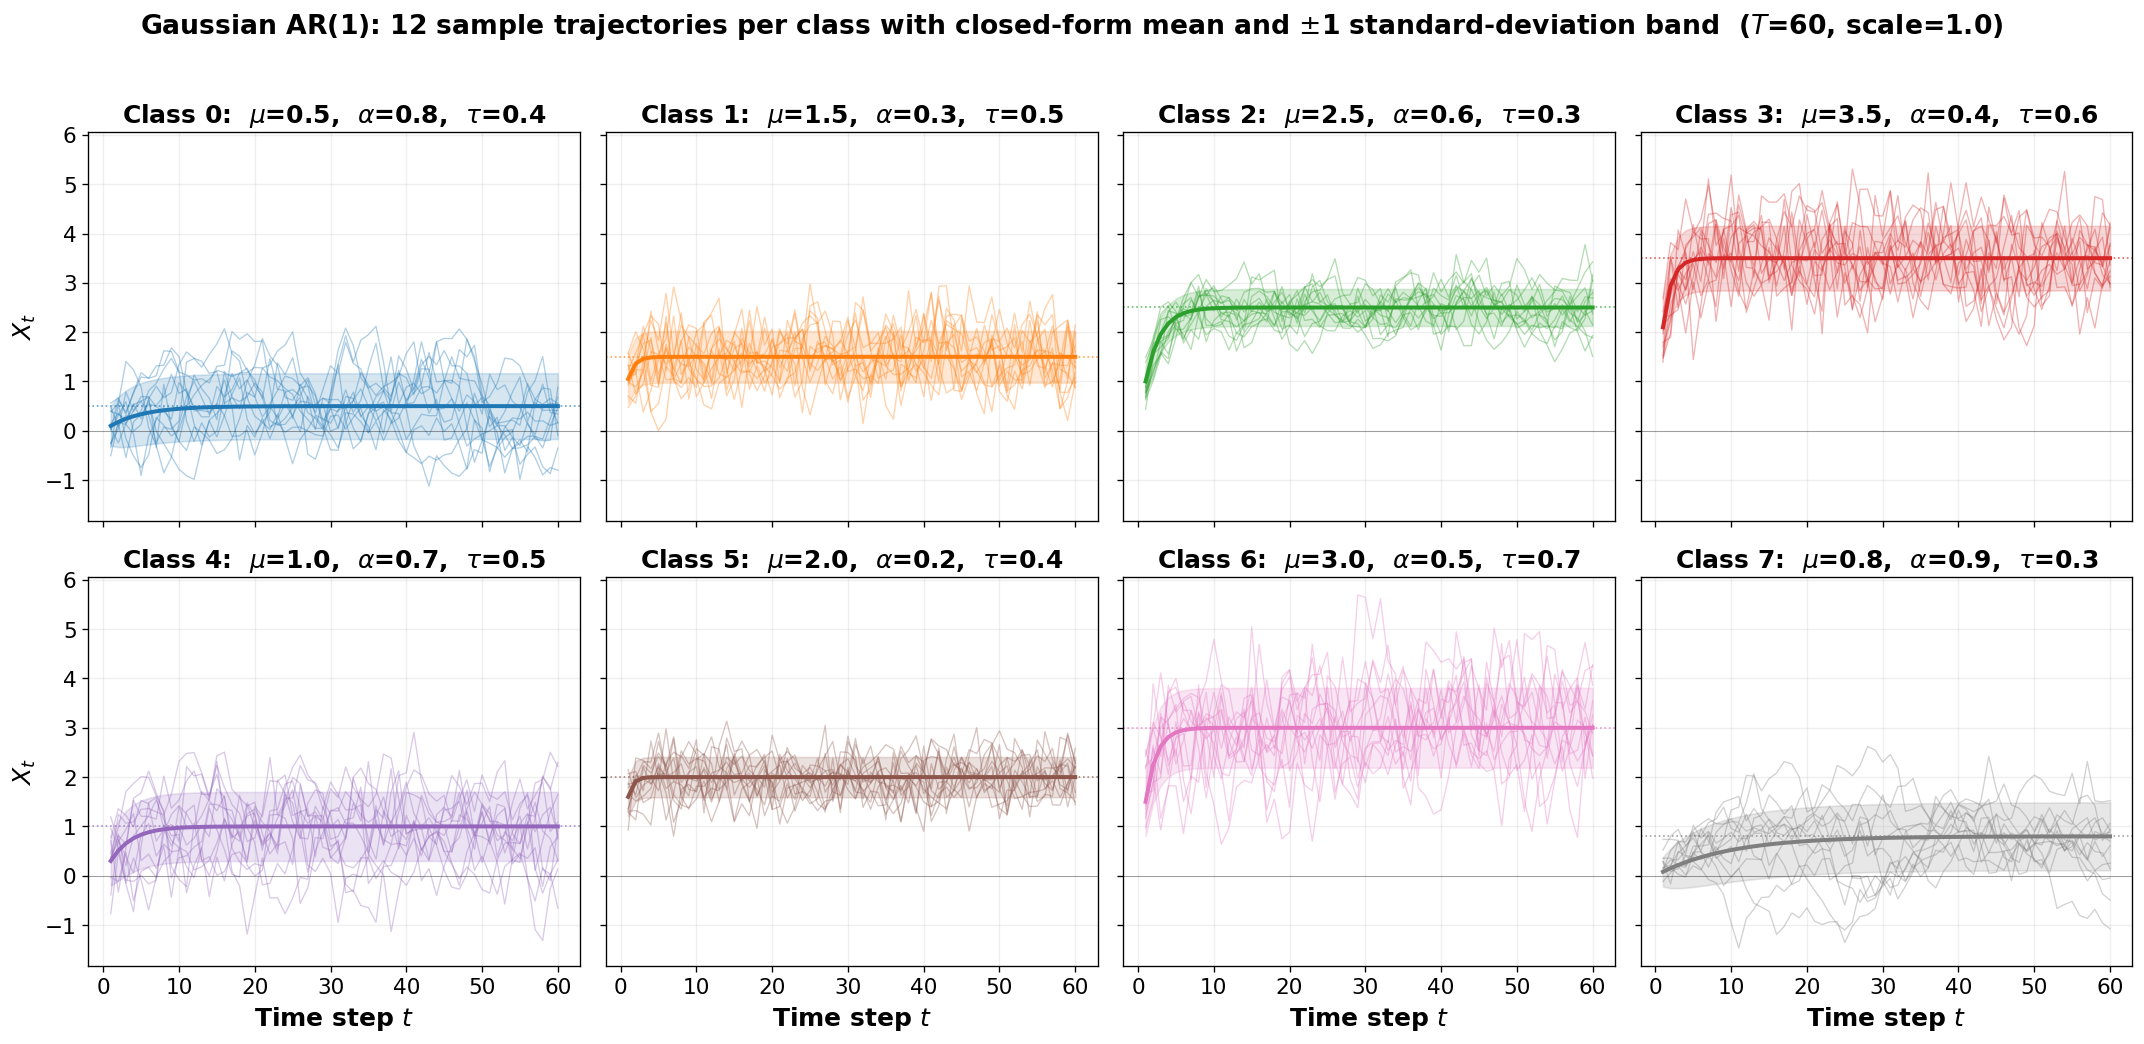

In [ ]:
# Plots sample trajectories for each class of the Gaussian AR(1) generator.
# Uses a 2x4 grid so each of the K=8 classes gets its own panel. Produces Figure 8.

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5), sharex=True, sharey=True)

for k, (ax, params) in enumerate(zip(axes.ravel(), ar_params_gaussian)):
    # Extracts this class's AR(1) parameters for labelling and moment computation.
    mu_k, alpha_k, tau_k = params['mu'], params['alpha'], params['tau']

    # Computes the closed-form mean and SD curves for this class.
    mean_curve, sd_curve = ar1_analytical_moments(mu_k, alpha_k, tau_k, T_viz)

    # Selects the first n_paths_per_class trajectories generated under this class.
    mask = S_gauss_viz == k
    class_trajs = X_gauss_viz[mask][:n_paths_per_class]

    # Plots each sample trajectory as a thin, slightly transparent line.
    for traj in class_trajs:
        ax.plot(t_axis, traj, color=class_colours[k], alpha=0.35, linewidth=0.8)

    # Shades the analytical +/- 1 SD envelope to show the typical spread.
    ax.fill_between(t_axis, mean_curve - sd_curve, mean_curve + sd_curve, color=class_colours[k], alpha=0.18)

    # Draws the analytical mean curve as a thick solid line for reference.
    ax.plot(t_axis, mean_curve, color=class_colours[k], linewidth=2.4)

    # Dotted horizontal line at the asymptotic mean mu_k.
    ax.axhline(mu_k, color=class_colours[k], linewidth=1.0, linestyle=":", alpha=0.7)

    # Horizontal line at zero to emphasise the starting point X_0 = 0.
    ax.axhline(0, color="k", linewidth=0.5, alpha=0.4)

    # Panel title with the class index and its three defining parameters.
    ax.set_title(f"Class {k}:  $\\mu$={mu_k},  $\\alpha$={alpha_k},  $\\tau$={tau_k}", fontsize=15, fontweight="bold")

    # Enlarges the tick labels so the numeric axes stay legible at this figure size.
    ax.tick_params(axis="both", labelsize=13)

    # Labels the x-axis only on the bottom row.
    if k >= 4:
        ax.set_xlabel("Time step $t$", fontsize=15, fontweight="bold")

    # Labels the y-axis only on the leftmost column.
    if k % 4 == 0:
        ax.set_ylabel("$X_t$", fontsize=15, fontweight="bold")

    ax.grid(alpha=0.2)

fig.suptitle(f"Gaussian AR(1): {n_paths_per_class} sample trajectories per class with closed-form mean and $\\pm$1 standard-deviation band  ($T$={T_viz}, scale=1.0)", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

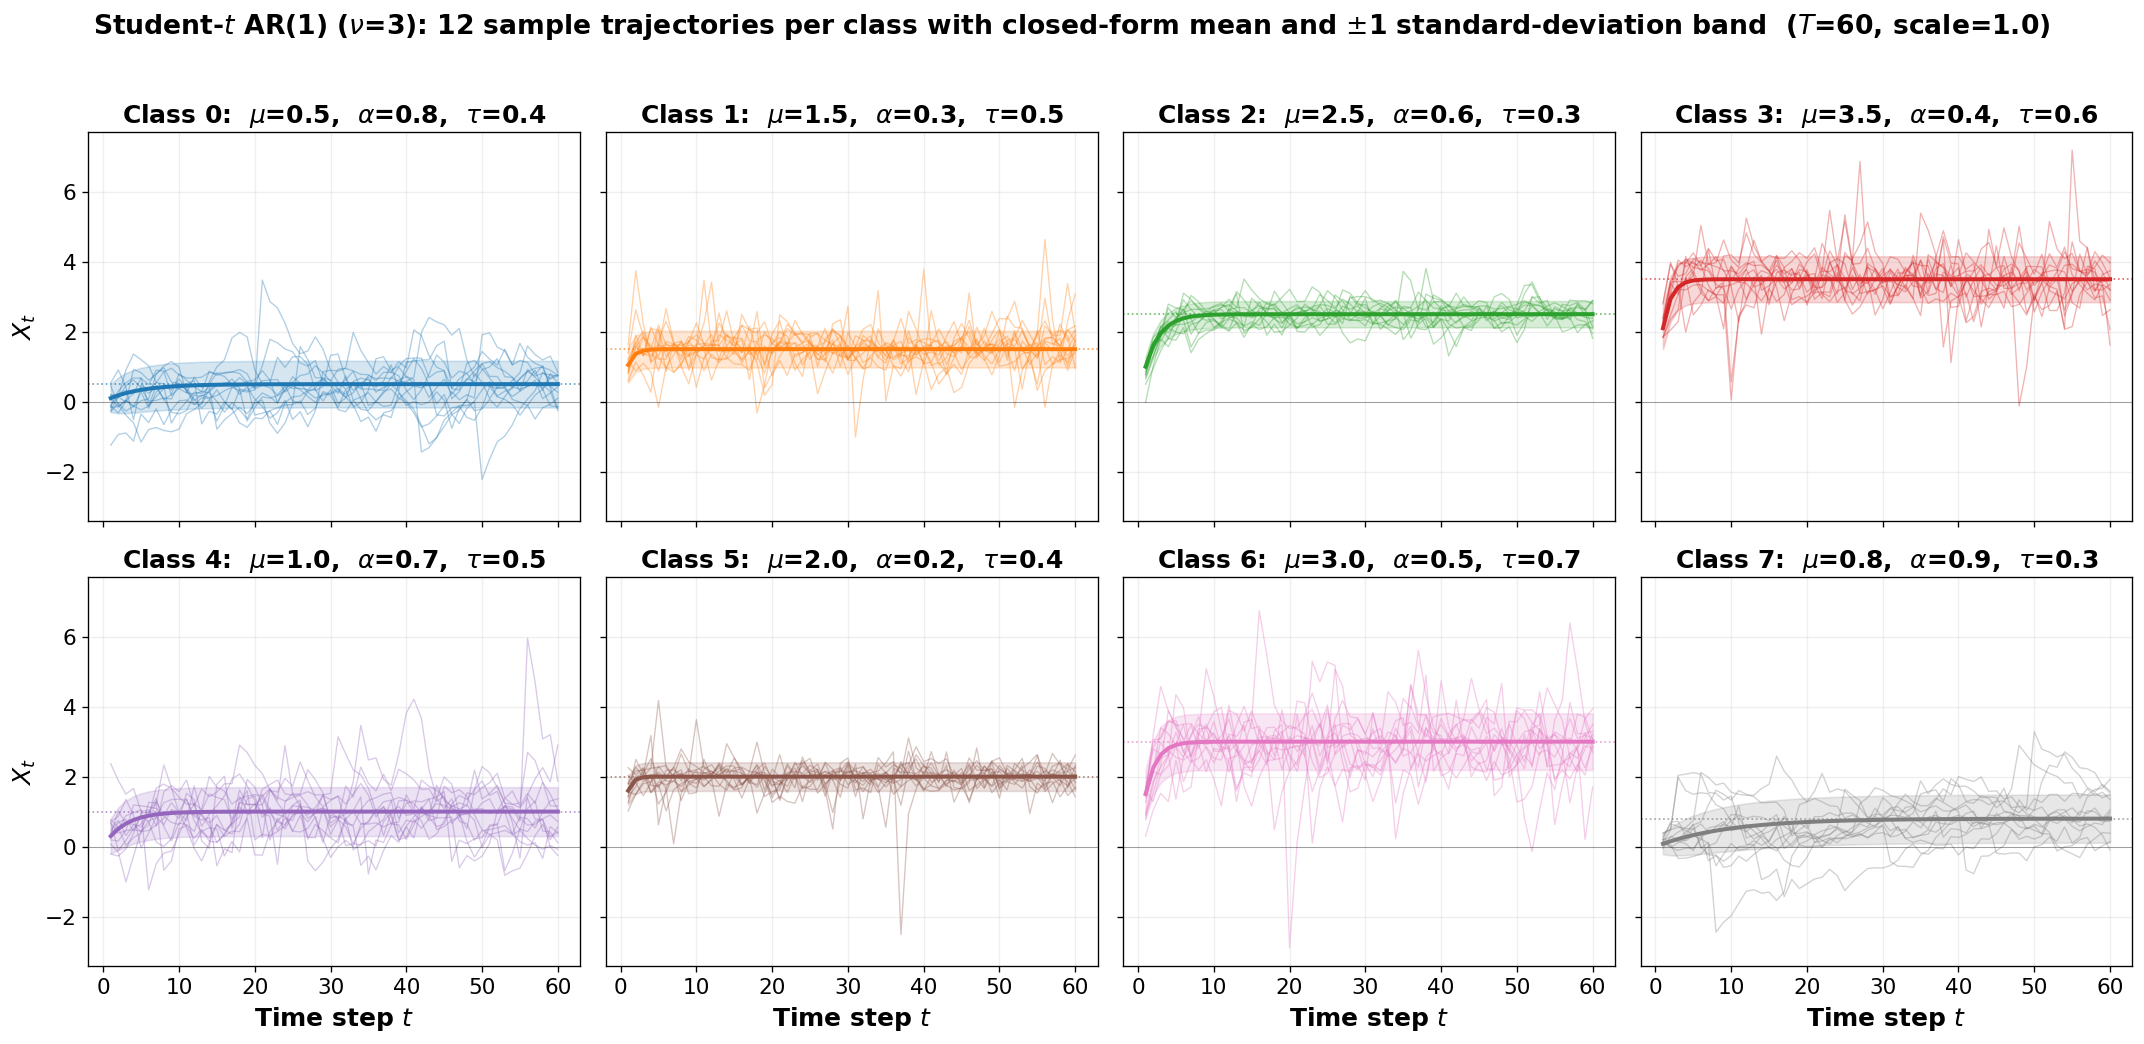

In [ ]:
# Same 2x4 layout for Student-t AR(1), which shares the Gaussian mean and variance.
# Any visual difference comes from occasional heavy-tail jumps caused by the nu=3 innovations.
# Produces Figure 9.

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5), sharex=True, sharey=True)

for k, (ax, params) in enumerate(zip(axes.ravel(), ar_params_student)):
    # Extracts this class's AR(1) parameters for labelling and moment computation.
    mu_k, alpha_k, tau_k = params['mu'], params['alpha'], params['tau']

    # Uses the same analytical moments as the Gaussian case (innovations are variance-matched).
    mean_curve, sd_curve = ar1_analytical_moments(mu_k, alpha_k, tau_k, T_viz)

    # Selects the first n_paths_per_class trajectories generated under this class.
    mask = S_stud_viz == k
    class_trajs = X_stud_viz[mask][:n_paths_per_class]

    # Plots each sample trajectory so heavy-tail jumps show up as sharp spikes.
    for traj in class_trajs:
        ax.plot(t_axis, traj, color=class_colours[k], alpha=0.35, linewidth=0.8)

    # Shades the analytical +/- 1 SD envelope, identical to the Gaussian case.
    ax.fill_between(t_axis, mean_curve - sd_curve, mean_curve + sd_curve, color=class_colours[k], alpha=0.18)

    # Draws the analytical mean curve.
    ax.plot(t_axis, mean_curve, color=class_colours[k], linewidth=2.4)

    # Dotted reference line at the asymptotic mean mu_k.
    ax.axhline(mu_k, color=class_colours[k], linewidth=1.0, linestyle=":", alpha=0.7)

    # Horizontal line at zero as the starting level X_0 = 0.
    ax.axhline(0, color="k", linewidth=0.5, alpha=0.4)

    # Panel title with the class index and its three defining parameters.
    ax.set_title(f"Class {k}:  $\\mu$={mu_k},  $\\alpha$={alpha_k},  $\\tau$={tau_k}", fontsize=15, fontweight="bold")

    ax.tick_params(axis="both", labelsize=13)

    # Labels the x-axis only on the bottom row.
    if k >= 4:
        ax.set_xlabel("Time step $t$", fontsize=15, fontweight="bold")

    # Labels the y-axis only on the leftmost column.
    if k % 4 == 0:
        ax.set_ylabel("$X_t$", fontsize=15, fontweight="bold")

    ax.grid(alpha=0.2)

fig.suptitle(f"Student-$t$ AR(1) ($\\nu$=3): {n_paths_per_class} sample trajectories per class with closed-form mean and $\\pm$1 standard-deviation band  ($T$={T_viz}, scale=1.0)", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

### Signed Bias Heatmaps

The next few cells produce the bias heatmaps used in Section 7.2 of the dissertation. Each cell in a heatmap shows the mean signed bias (estimated MI minus true MI) at the corresponding $(\lambda, T)$ combination, averaged over the 3 repetitions. Blue cells indicate underestimation, red cells indicate overestimation, and white means the estimator is close to the truth.

First is the ground-truth reference heatmap (Figure 11), followed by the classifier-based estimators (Figures 10 and 12) and the neural estimators (Figures 13 and 14).

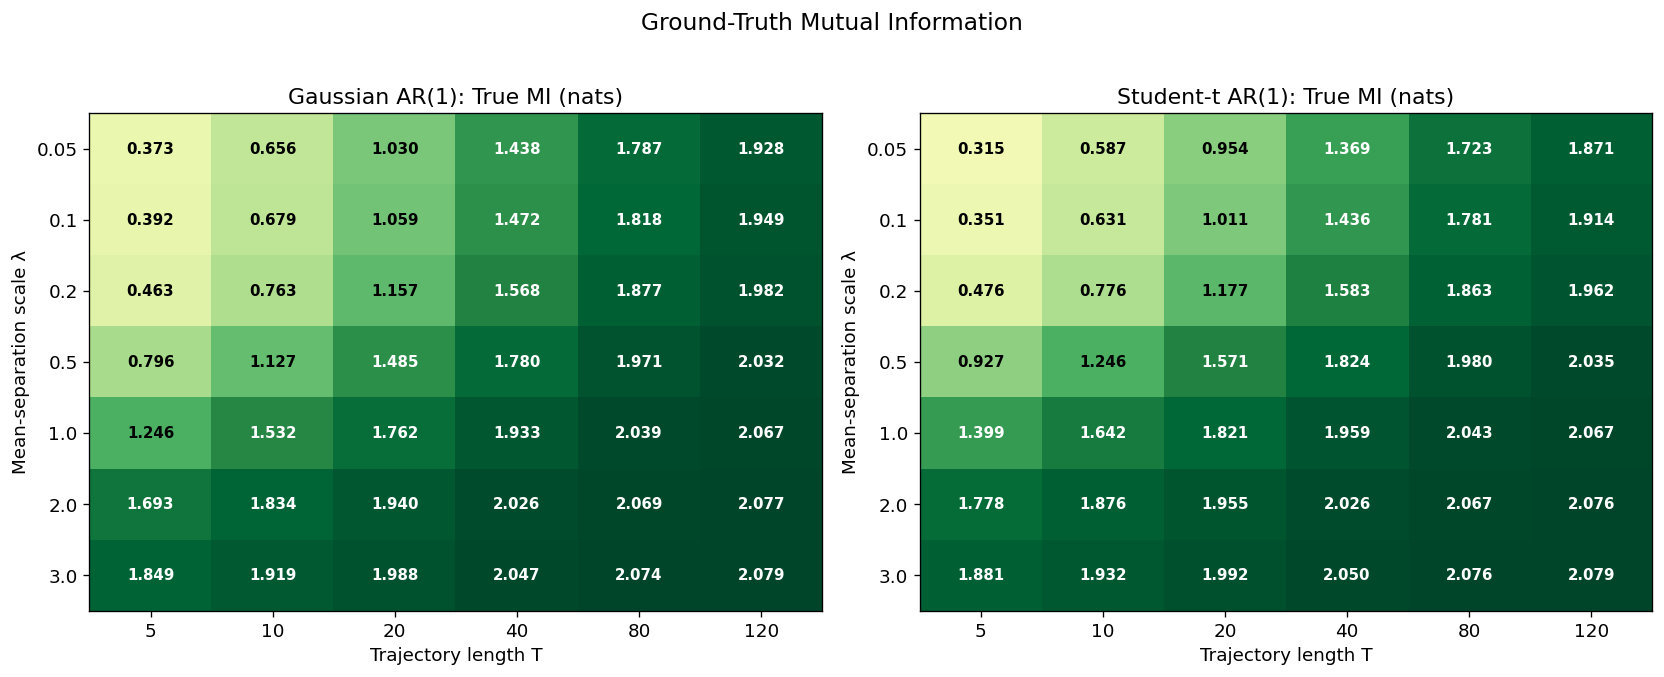

In [ ]:
# True MI reference heatmaps, one panel per AR(1) family. Produces Figure 11.

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Shared colour range across both families.
all_true = []
for family_name in ["Gaussian", "Student-t"]:
    for s in mu_scales:
        for T in T_values:
            all_true.append(true_mis_grid[family_name][s][T])
vmin, vmax = 0, max(all_true)

for col, family_name in enumerate(["Gaussian", "Student-t"]):
    ax = axes[col]

    # Builds the true MI matrix with rows for scales and columns for T.
    mi_matrix = np.zeros((len(mu_scales), len(T_values)))
    for i, s in enumerate(mu_scales):
        for j, T in enumerate(T_values):
            mi_matrix[i, j] = true_mis_grid[family_name][s][T]

    # Heatmap with a sequential colourmap (low MI = light, high MI = dark).
    im = ax.imshow(mi_matrix, cmap="YlGn", vmin=vmin, vmax=vmax, aspect="auto", origin="upper")

    # Annotates each cell with the true MI value in nats.
    for i in range(len(mu_scales)):
        for j in range(len(T_values)):
            val = mi_matrix[i, j]
            # Switches to white text on dark cells for readability.
            colour = "white" if val > vmax * 0.65 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9, color=colour, fontweight="bold")

    ax.set_xticks(range(len(T_values)))
    ax.set_xticklabels([str(T) for T in T_values])
    ax.set_yticks(range(len(mu_scales)))
    ax.set_yticklabels([str(s) for s in mu_scales])
    ax.set_xlabel("Trajectory length T")
    ax.set_ylabel("Mean-separation scale λ")
    ax.set_title(f"{family_name} AR(1): True MI (nats)")

fig.suptitle("Ground-Truth Mutual Information", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

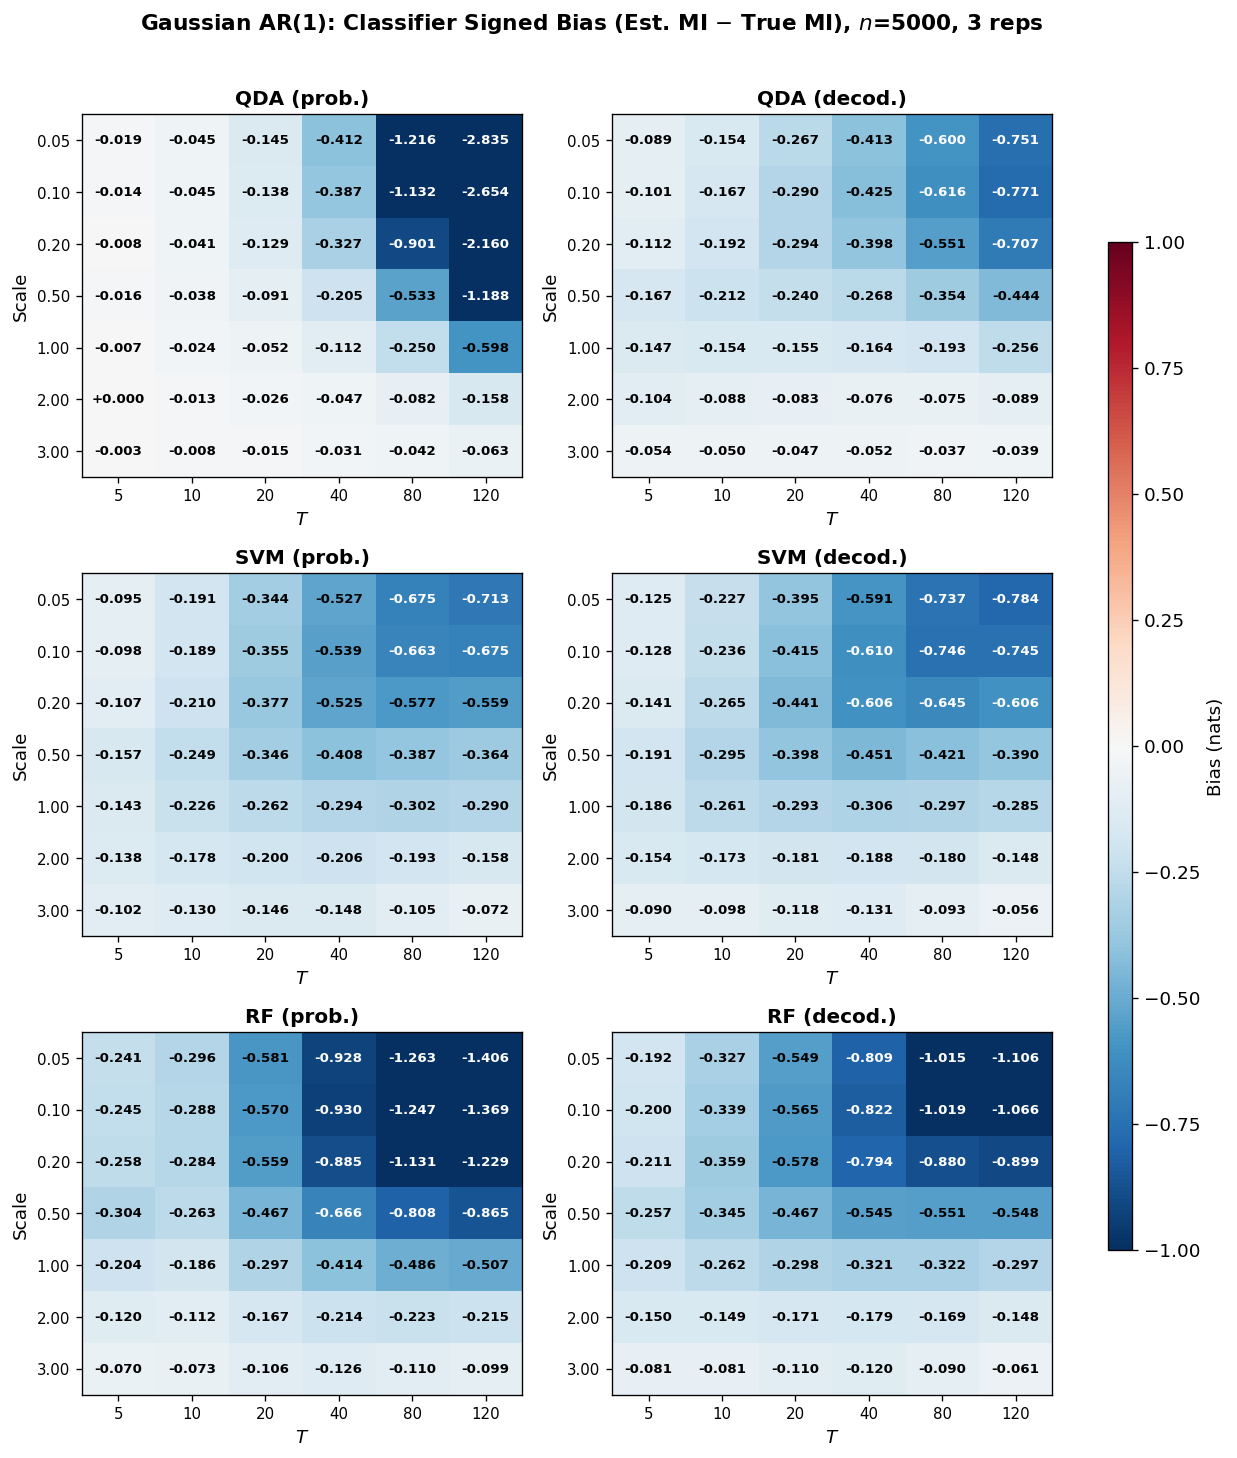

In [ ]:
import matplotlib.colors as mcolors

# Display labels for the estimator keys, used in panel titles.
est_display = {
    "QDA|slemi": "QDA (prob.)",
    "QDA|decode": "QDA (decod.)",
    "SVM (Platt)|slemi": "SVM (prob.)",
    "SVM (Platt)|decode": "SVM (decod.)",
    "Random Forest|slemi": "RF (prob.)",
    "Random Forest|decode": "RF (decod.)",
    "MINE|mine": "MINE",
    "VCE'|vce_prime": "VCE'",
}

# Classifier estimator keys in row order: QDA, SVM, RF.
# Each row pairs the probability-based variant with the decoding-based variant.
classifier_keys = [
    "QDA|slemi", "QDA|decode",
    "SVM (Platt)|slemi", "SVM (Platt)|decode",
    "Random Forest|slemi", "Random Forest|decode",
]

# 3x2 figure with rows for each classifier and columns for prob. vs decode.
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# Collects all bias values across classifier estimators to determine the colour range.
all_biases = []
for ek in classifier_keys:
    for s in mu_scales:
        for T in T_values:
            # Signed bias = mean estimate - true MI.
            mean_est = np.mean(results_grid["Gaussian"][ek][s][T])
            true_mi = true_mis_grid["Gaussian"][s][T]
            all_biases.append(mean_est - true_mi)

# Caps the colour range at 1.0 nats so outliers don't dominate.
vmax = min(max(abs(min(all_biases)), abs(max(all_biases))), 1.0)
# Centres the colourmap at zero: blue = underestimate, red = overestimate.
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for idx, ek in enumerate(classifier_keys):
    ax = axes.ravel()[idx]

    # Builds the bias matrix with rows for scales and columns for T.
    bias_matrix = np.zeros((len(mu_scales), len(T_values)))
    for i, s in enumerate(mu_scales):
        for j, T in enumerate(T_values):
            mean_est = np.mean(results_grid["Gaussian"][ek][s][T])
            true_mi = true_mis_grid["Gaussian"][s][T]
            bias_matrix[i, j] = mean_est - true_mi

    # Heatmap with colours centred at zero.
    im = ax.imshow(bias_matrix, cmap="RdBu_r", norm=norm, aspect="auto", origin="upper")

    # Annotates each cell with the numeric bias value.
    for i in range(len(mu_scales)):
        for j in range(len(T_values)):
            val = bias_matrix[i, j]
            # Switches text colour to white when the background is too dark.
            colour = "white" if abs(val) > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=8, color=colour, fontweight="bold")

    # Tick labels for the trajectory length and scale axes.
    ax.set_xticks(range(len(T_values)))
    ax.set_xticklabels(T_values, fontsize=9)
    ax.set_yticks(range(len(mu_scales)))
    ax.set_yticklabels([f"{s:.2f}" for s in mu_scales], fontsize=9)
    ax.set_xlabel("$T$")
    ax.set_ylabel("Scale")
    # Uses the display name from the lookup dictionary as the panel title.
    ax.set_title(est_display[ek], fontsize=12, fontweight="bold")


fig.suptitle(f"Gaussian AR(1): Classifier Signed Bias (Est. MI $-$ True MI), $n$={n_samples}, {n_repeats} reps", fontsize=13, fontweight="bold", y=1.01)

# Shared colourbar on the right side.
fig.subplots_adjust(right=0.90, hspace=0.35, wspace=0.30)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Bias (nats)")

plt.tight_layout(rect=[0, 0, 0.90, 1.0])
plt.show()

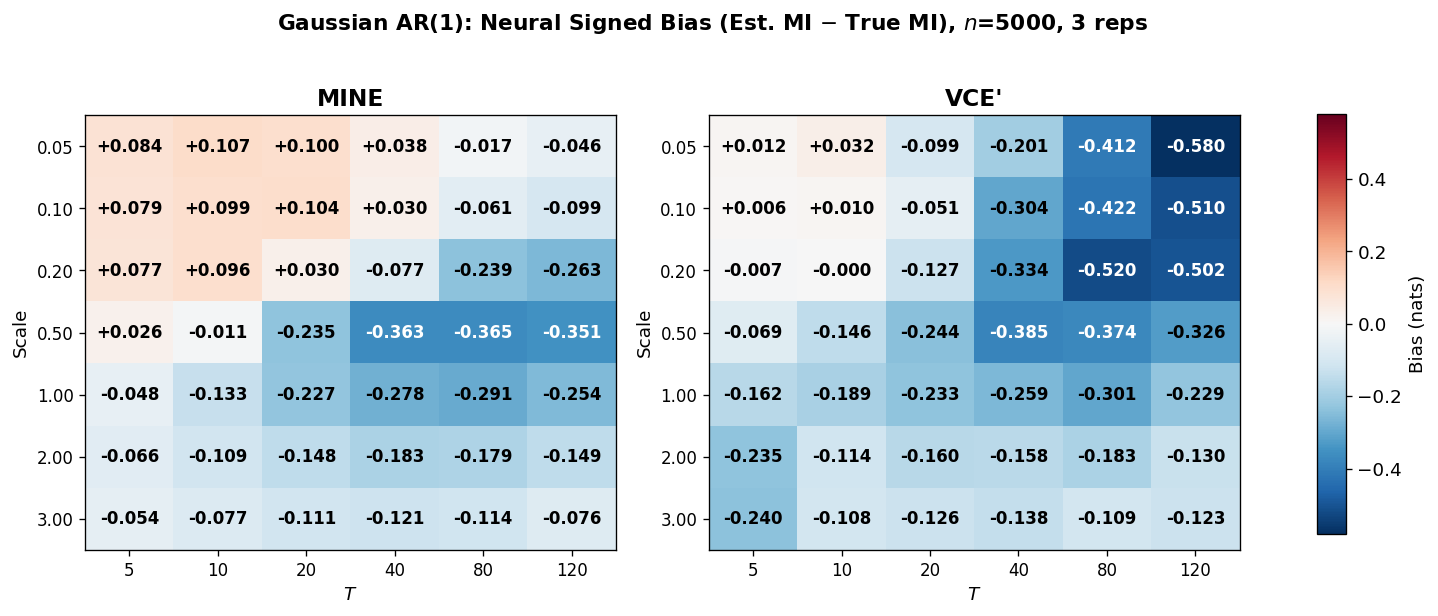

In [ ]:
# Neural estimator keys: MINE and VCE'.
neural_keys = ["MINE|mine", "VCE'|vce_prime"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Collects all bias values across neural estimators for the colour range.
all_biases = []
for ek in neural_keys:
    for s in mu_scales:
        for T in T_values:
            # Signed bias for this estimator, scale, and trajectory length.
            mean_est = np.mean(results_grid["Gaussian"][ek][s][T])
            true_mi = true_mis_grid["Gaussian"][s][T]
            all_biases.append(mean_est - true_mi)

# Caps the colour range at 1.0 nats.
vmax = min(max(abs(min(all_biases)), abs(max(all_biases))), 1.0)
# Centres the colourmap at zero.
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for idx, ek in enumerate(neural_keys):
    ax = axes[idx]

    # Builds the bias matrix with rows for scales and columns for T.
    bias_matrix = np.zeros((len(mu_scales), len(T_values)))
    for i, s in enumerate(mu_scales):
        for j, T in enumerate(T_values):
            mean_est = np.mean(results_grid["Gaussian"][ek][s][T])
            true_mi = true_mis_grid["Gaussian"][s][T]
            bias_matrix[i, j] = mean_est - true_mi

    # Heatmap with the shared colour scale.
    im = ax.imshow(bias_matrix, cmap="RdBu_r", norm=norm, aspect="auto", origin="upper")

    # Annotates each cell with the numeric bias.
    for i in range(len(mu_scales)):
        for j in range(len(T_values)):
            val = bias_matrix[i, j]
            colour = "white" if abs(val) > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=10, color=colour, fontweight="bold")


    ax.set_xticks(range(len(T_values)))
    ax.set_xticklabels(T_values, fontsize=10)
    ax.set_yticks(range(len(mu_scales)))
    ax.set_yticklabels([f"{s:.2f}" for s in mu_scales], fontsize=10)
    ax.set_xlabel("$T$", fontsize=11)
    ax.set_ylabel("Scale", fontsize=11)
    ax.set_title(est_display[ek], fontsize=14, fontweight="bold")


fig.suptitle(f"Gaussian AR(1): Neural Signed Bias (Est. MI $-$ True MI), $n$={n_samples}, {n_repeats} reps", fontsize=13, fontweight="bold", y=1.02)

# Shared colourbar on the right side.
fig.subplots_adjust(right=0.88, wspace=0.30)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Bias (nats)")

plt.tight_layout(rect=[0, 0, 0.88, 1.0])
plt.show()

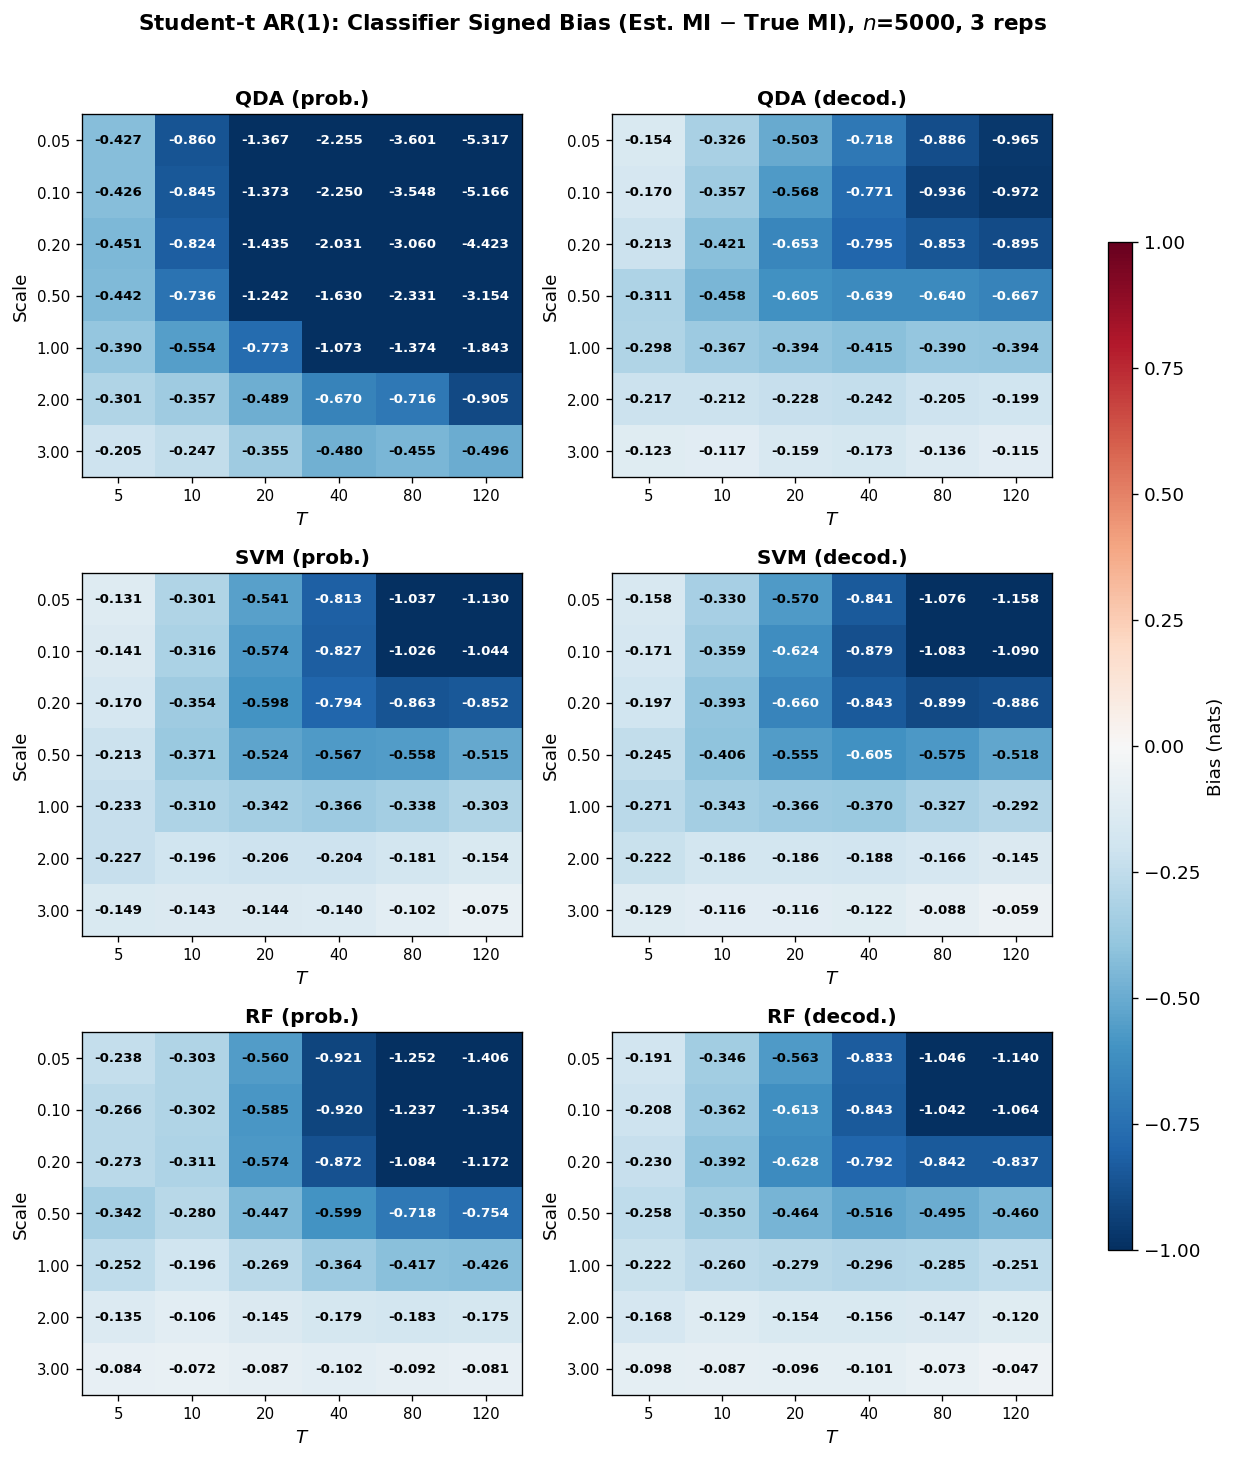

In [ ]:
# Same classifier keys as the Gaussian case for direct comparison.
classifier_keys = [
    "QDA|slemi", "QDA|decode",
    "SVM (Platt)|slemi", "SVM (Platt)|decode",
    "Random Forest|slemi", "Random Forest|decode",
]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# Collects all bias values across classifier estimators for the Student-t family.
all_biases = []
for ek in classifier_keys:
    for s in mu_scales:
        for T in T_values:
            # Signed bias under the Student-t data-generating process.
            mean_est = np.mean(results_grid["Student-t"][ek][s][T])
            true_mi = true_mis_grid["Student-t"][s][T]
            all_biases.append(mean_est - true_mi)

# Caps the colour range at 1.0 nats.
vmax = min(max(abs(min(all_biases)), abs(max(all_biases))), 1.0)
# Centres the colourmap at zero.
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for idx, ek in enumerate(classifier_keys):
    ax = axes.ravel()[idx]

    # Builds the bias matrix for this estimator under the Student-t family.
    bias_matrix = np.zeros((len(mu_scales), len(T_values)))
    for i, s in enumerate(mu_scales):
        for j, T in enumerate(T_values):
            mean_est = np.mean(results_grid["Student-t"][ek][s][T])
            true_mi = true_mis_grid["Student-t"][s][T]
            bias_matrix[i, j] = mean_est - true_mi

    # Heatmap with colours centred at zero.
    im = ax.imshow(bias_matrix, cmap="RdBu_r", norm=norm, aspect="auto", origin="upper")

    # Annotates each cell with the signed bias value.
    for i in range(len(mu_scales)):
        for j in range(len(T_values)):
            val = bias_matrix[i, j]
            colour = "white" if abs(val) > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=8, color=colour, fontweight="bold")

    # Tick labels for the trajectory length and scale axes.
    ax.set_xticks(range(len(T_values)))
    ax.set_xticklabels(T_values, fontsize=9)
    ax.set_yticks(range(len(mu_scales)))
    ax.set_yticklabels([f"{s:.2f}" for s in mu_scales], fontsize=9)
    ax.set_xlabel("$T$")
    ax.set_ylabel("Scale")
    ax.set_title(est_display[ek], fontsize=12, fontweight="bold")


fig.suptitle(f"Student-t AR(1): Classifier Signed Bias (Est. MI $-$ True MI), $n$={n_samples}, {n_repeats} reps", fontsize=13, fontweight="bold", y=1.01)

# Shared colourbar on the right side.
fig.subplots_adjust(right=0.90, hspace=0.35, wspace=0.30)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Bias (nats)")

plt.tight_layout(rect=[0, 0, 0.90, 1.0])
plt.show()

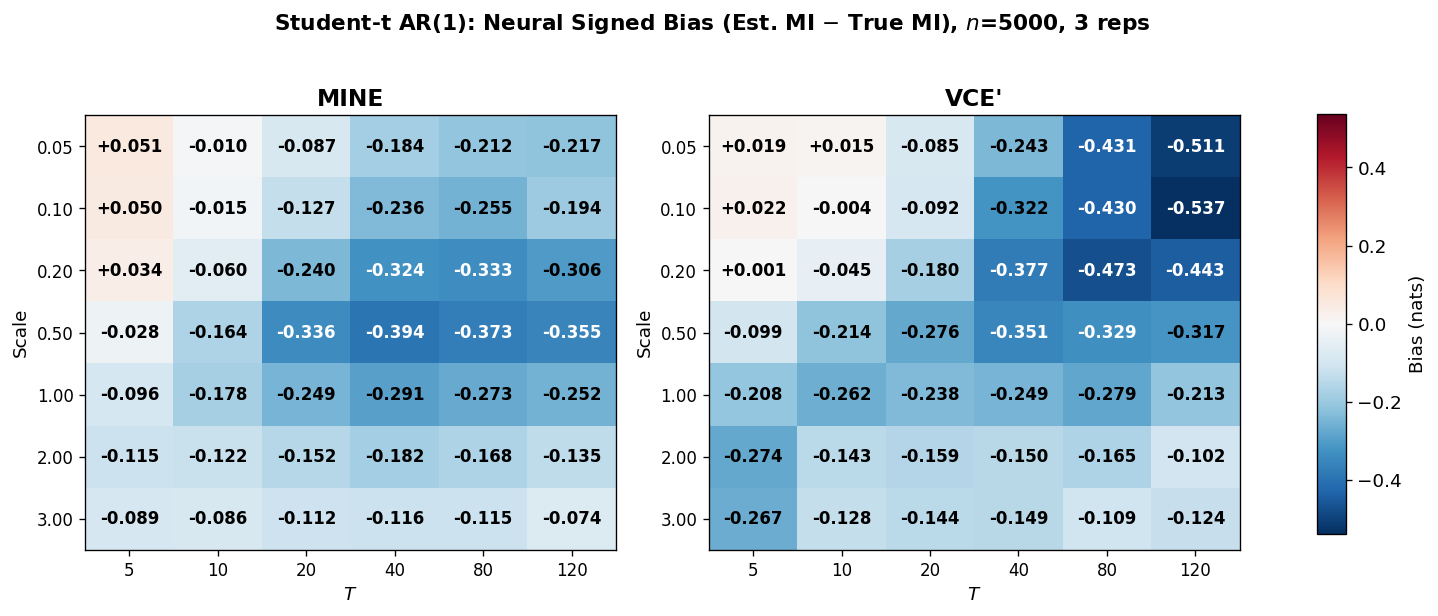

In [ ]:
# Neural estimator keys for the Student-t comparison.
neural_keys = ["MINE|mine", "VCE'|vce_prime"]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Collects all bias values across neural estimators for the Student-t family.
all_biases = []
for ek in neural_keys:
    for s in mu_scales:
        for T in T_values:
            # Signed bias for this neural estimator under Student-t noise.
            mean_est = np.mean(results_grid["Student-t"][ek][s][T])
            true_mi = true_mis_grid["Student-t"][s][T]
            all_biases.append(mean_est - true_mi)

# Caps the colour range at 1.0 nats.
vmax = min(max(abs(min(all_biases)), abs(max(all_biases))), 1.0)
# Centres the colourmap at zero.
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for idx, ek in enumerate(neural_keys):
    ax = axes[idx]

    # Builds the bias matrix for this neural estimator under the Student-t family.
    bias_matrix = np.zeros((len(mu_scales), len(T_values)))
    for i, s in enumerate(mu_scales):
        for j, T in enumerate(T_values):
            mean_est = np.mean(results_grid["Student-t"][ek][s][T])
            true_mi = true_mis_grid["Student-t"][s][T]
            bias_matrix[i, j] = mean_est - true_mi

    # Heatmap with the shared colour scale.
    im = ax.imshow(bias_matrix, cmap="RdBu_r", norm=norm,
                   aspect="auto", origin="upper")

    # Annotates each cell with the signed bias.
    for i in range(len(mu_scales)):
        for j in range(len(T_values)):
            val = bias_matrix[i, j]
            colour = "white" if abs(val) > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=10, color=colour, fontweight="bold")

    # Slightly larger tick labels for readability.
    ax.set_xticks(range(len(T_values)))
    ax.set_xticklabels(T_values, fontsize=10)
    ax.set_yticks(range(len(mu_scales)))
    ax.set_yticklabels([f"{s:.2f}" for s in mu_scales], fontsize=10)
    ax.set_xlabel("$T$", fontsize=11)
    ax.set_ylabel("Scale", fontsize=11)
    ax.set_title(est_display[ek], fontsize=14, fontweight="bold")

fig.suptitle(f"Student-t AR(1): Neural Signed Bias (Est. MI $-$ True MI), $n$={n_samples}, {n_repeats} reps", fontsize=13, fontweight="bold", y=1.02)

# Shared colourbar on the right side.
fig.subplots_adjust(right=0.88, wspace=0.30)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Bias (nats)")

plt.tight_layout(rect=[0, 0, 0.88, 1.0])
plt.show()